In [1]:
# Chcecking for GPU and CUDA version

import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

True
11.8
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')

Using device : cuda


In [3]:
# Importing necessary libraries

import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import os

In [4]:
# importing the ResNet50 model 

model = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)

# Unfreezing the last layer only

In [5]:
# Freezing the layers of the model
for param in model.parameters():
    param.requires_grad = False

In [6]:
# Modifying the final fully connected layer of the model to match the number of classes of Brain Tumor Dataset

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p = 0.3),
    nn.Linear(num_features,4)
)    # 4 classes in the brain tumor dataset

In [7]:
# Providing model to the device

model = model.to(device)

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [9]:
# Importing the Dataset and creating dataloaders

base_dir = '.'

train_dataset = datasets.ImageFolder(root=os.path.join(base_dir, 'Datasets', 'Training'), transform = transform)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

val_dataset = datasets.ImageFolder(root=os.path.join(base_dir, 'Datasets', 'Testing'), transform = transform)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

In [10]:
# Defining the criterion and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr = 0.0001)

In [11]:
# Defining the training loop for the model
epochs = 100

for epoch in range(epochs):
    model.train()
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}/{epochs}, Loss : {loss.item(): .4f}')

Epoch 1/100, Loss :  1.1243
Epoch 2/100, Loss :  0.8120
Epoch 3/100, Loss :  0.8186
Epoch 4/100, Loss :  0.6496
Epoch 5/100, Loss :  0.6512
Epoch 6/100, Loss :  0.5628
Epoch 7/100, Loss :  0.6422
Epoch 8/100, Loss :  0.4326
Epoch 9/100, Loss :  0.6795
Epoch 10/100, Loss :  0.3758
Epoch 11/100, Loss :  0.4976
Epoch 12/100, Loss :  0.4872
Epoch 13/100, Loss :  0.5277
Epoch 14/100, Loss :  0.4491
Epoch 15/100, Loss :  0.3523
Epoch 16/100, Loss :  0.5311
Epoch 17/100, Loss :  0.4824
Epoch 18/100, Loss :  0.4127
Epoch 19/100, Loss :  0.3511
Epoch 20/100, Loss :  0.4138
Epoch 21/100, Loss :  0.3726
Epoch 22/100, Loss :  0.3355
Epoch 23/100, Loss :  0.3870
Epoch 24/100, Loss :  0.3209
Epoch 25/100, Loss :  0.3056
Epoch 26/100, Loss :  0.3409
Epoch 27/100, Loss :  0.2993
Epoch 28/100, Loss :  0.3280
Epoch 29/100, Loss :  0.1496
Epoch 30/100, Loss :  0.2689
Epoch 31/100, Loss :  0.4801
Epoch 32/100, Loss :  0.2781
Epoch 33/100, Loss :  0.2689
Epoch 34/100, Loss :  0.3067
Epoch 35/100, Loss :  0

In [12]:
# Validating the model on the validation dataset

model.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():
    
    for images, labels in val_loader:
        images,labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
accuracy = 100 * correct/total
avg_loss = val_loss/len(val_loader)

print(f'Validation Accuracy : {accuracy: .2f}%')
print(f'Validation Loss : {avg_loss: .4f}')

Validation Accuracy :  86.81%
Validation Loss :  0.4198


In [13]:
# Classes of Brain Tumor in the Dataset

class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

Analayzing the Classification by the model

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

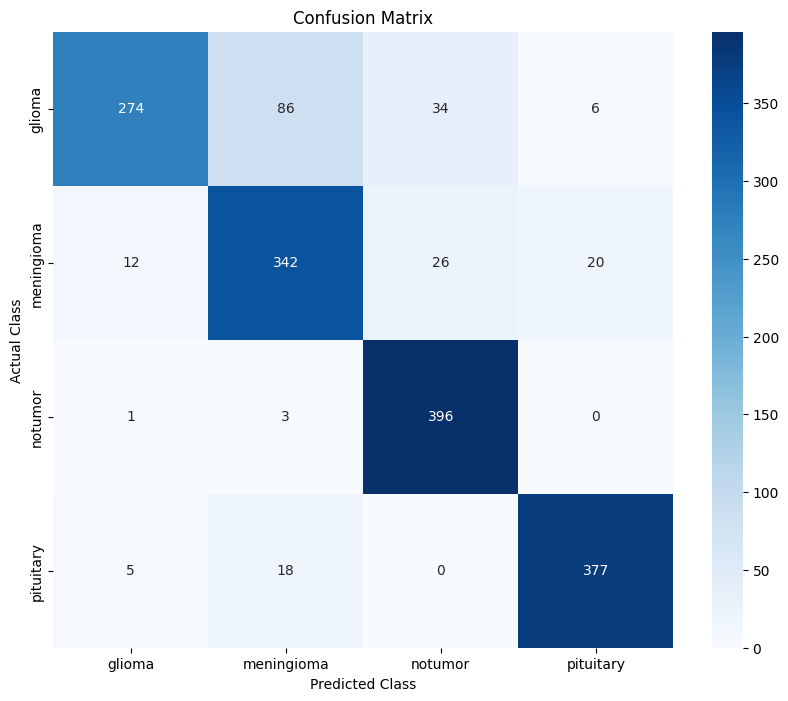

In [15]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
# Creating the Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes


#Plotting using Seaborn

plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

In [16]:
# Generating the classification report

from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names = class_names)

print('Classification Report: \n', report)

Classification Report: 
               precision    recall  f1-score   support

      glioma       0.94      0.69      0.79       400
  meningioma       0.76      0.85      0.81       400
     notumor       0.87      0.99      0.93       400
   pituitary       0.94      0.94      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



# Unfreezing the Layer 4 also in the ResNet50 model

In [17]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [18]:
# Increasing the learning rate as we have unfrozen the last layer of the model
optimizer = optim.Adam(model.parameters(), lr = 1e-6)

In [19]:
#Redefining the training loop for the model after unfreezing the layers
epochs = 100

for epoch in range(epochs):
    model.train()
    
    for images, labels in  train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch {epoch + 1}/{epochs}, Loss : {loss.item():.4f}')

Epoch 1/100, Loss : 0.3298
Epoch 2/100, Loss : 0.3692
Epoch 3/100, Loss : 0.1824
Epoch 4/100, Loss : 0.1961
Epoch 5/100, Loss : 0.1512
Epoch 6/100, Loss : 0.3906
Epoch 7/100, Loss : 0.1829
Epoch 8/100, Loss : 0.0947
Epoch 9/100, Loss : 0.1298
Epoch 10/100, Loss : 0.1200
Epoch 11/100, Loss : 0.1190
Epoch 12/100, Loss : 0.2227
Epoch 13/100, Loss : 0.1184
Epoch 14/100, Loss : 0.0564
Epoch 15/100, Loss : 0.0718
Epoch 16/100, Loss : 0.1676
Epoch 17/100, Loss : 0.0571
Epoch 18/100, Loss : 0.1023
Epoch 19/100, Loss : 0.0717
Epoch 20/100, Loss : 0.2628
Epoch 21/100, Loss : 0.1405
Epoch 22/100, Loss : 0.1155
Epoch 23/100, Loss : 0.1280
Epoch 24/100, Loss : 0.1470
Epoch 25/100, Loss : 0.1574
Epoch 26/100, Loss : 0.2263
Epoch 27/100, Loss : 0.0902
Epoch 28/100, Loss : 0.0686
Epoch 29/100, Loss : 0.0834
Epoch 30/100, Loss : 0.0669
Epoch 31/100, Loss : 0.0496
Epoch 32/100, Loss : 0.0441
Epoch 33/100, Loss : 0.2168
Epoch 34/100, Loss : 0.2753
Epoch 35/100, Loss : 0.1307
Epoch 36/100, Loss : 0.1653
E

In [20]:
# Validating the model with the unfroozen layers on the validation dataset

model.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():
    
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _,predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
accuracy = 100 * correct/total
avg_loss = val_loss/len(val_loader)

print(f'Validation Accuracy : {accuracy:.2f}%')
print(f'Validation Loss : {avg_loss:.4f}')

Validation Accuracy : 91.62%
Validation Loss : 0.3993


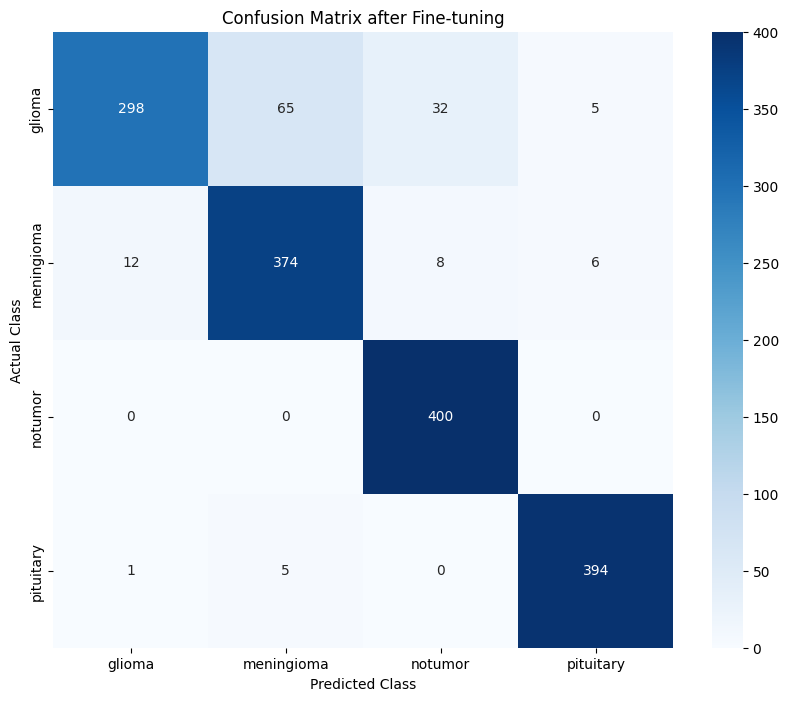

In [22]:
#  Visualizing the confusion matrix of the fine-tuned model

# Collecting the predictions and labels for the validation dataset
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images,labels = images.to(device), labels.to(device)
        outputs = model(images)
        _,preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
# Creating the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

#plotting the confusion matrix using seaborn
plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix after Fine-tuning')
plt.show()

In [23]:
# Generating the classification report of fine-tuned model

report = classification_report(all_labels, all_preds, target_names = class_names)

print('Classification Report after fine-tuning : \n', report)

Classification Report after fine-tuning : 
               precision    recall  f1-score   support

      glioma       0.96      0.74      0.84       400
  meningioma       0.84      0.94      0.89       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.97      0.98      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.91      1600
weighted avg       0.92      0.92      0.91      1600

